# Synthetic Gaussian Pretraining Data — Visualisation

Loads the saved synthetic dataset from `synthetic-gaussian-pretrain/` and produces
diagnostic figures, saving each to `synthetic-gaussian-pretrain/plots/`.

**Run `pretrain/generate_data.py` first to produce the dataset.**

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Add project root to path
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

In [2]:
# ============================================================
# CONFIG — edit these to match your generate_data.py settings
# ============================================================

MAIN_PATH   = "/Users/georgeissa/Documents/AC/SPE-AC-VAE"
DATA_DIR    = os.path.join(MAIN_PATH, "Data", "datasets", "synthetic-gaussian-pretrain")
PLOTS_DIR   = os.path.join(DATA_DIR, "plots")
BETA        = 10.0
DTAU        = 0.05

os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Data dir  : {DATA_DIR}")
print(f"Plots dir : {PLOTS_DIR}")

Data dir  : /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain
Plots dir : /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain/plots


## 1 · Load dataset

In [3]:
G_hat   = np.loadtxt(os.path.join(DATA_DIR, "Ghat_clean.csv"),  delimiter=",")
G_tilde = np.loadtxt(os.path.join(DATA_DIR, "Gbins_synthetic.csv"), delimiter=",")
params  = np.loadtxt(os.path.join(DATA_DIR, "params.csv"), delimiter=",", skiprows=1)

mus    = params[:, 0]
sigmas = params[:, 1]
N, L_tau = G_hat.shape
taus = np.linspace(0.0, BETA - DTAU, L_tau)

print(f"N = {N},  L_tau = {L_tau}")
print(f"mu    : min={mus.min():.3f}  max={mus.max():.3f}  mean={mus.mean():.3f}")
print(f"sigma : min={sigmas.min():.3f}  max={sigmas.max():.3f}  mean={sigmas.mean():.3f}")
print(f"G(tau=0) : min={G_hat[:,0].min():.4f}  max={G_hat[:,0].max():.4f}")

N = 1000,  L_tau = 200
mu    : min=-0.499  max=0.499  mean=-0.003
sigma : min=0.300  max=2.996  mean=1.197
G(tau=0) : min=0.0918  max=0.9030


## 2 · Overview (6-panel figure)

- **(0,0)** 2D scatter (mu, log-sigma) — should fill the rectangle uniformly
- **(0,1)** Histogram of mu — should be flat (Uniform)
- **(0,2)** Histogram of log(sigma) — should be flat (LogUniform)
- **(1,0)** Sample G(τ) curves — colored by mu
- **(1,1)** Sample A(ω) = Gaussian curves — colored by mu
- **(1,2)** G(τ=0) distribution — spans [0,1] via Fermi function

In [4]:
from pretrain.synthetic_data import visualize_synthetic_dataset  # type: ignore

save_path = os.path.join(PLOTS_DIR, "dataset_overview.pdf")
visualize_synthetic_dataset(DATA_DIR, BETA, DTAU, save_path=save_path, n_show=40)
print(f"Saved → {save_path}")

  Dataset overview saved to: /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain/plots/dataset_overview.pdf
Saved → /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain/plots/dataset_overview.pdf


## 3 · Parameter coverage check

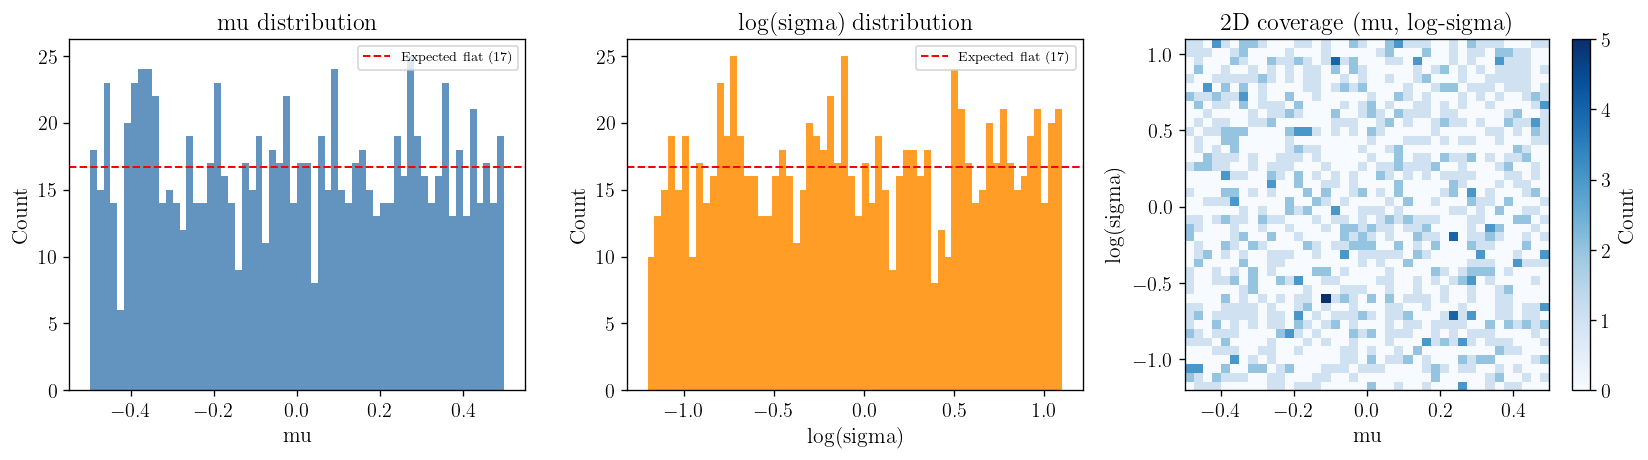

Saved → /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain/plots/parameter_coverage.pdf


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# mu histogram with expected flat line
ax = axes[0]
counts, edges, _ = ax.hist(mus, bins=60, color="steelblue", edgecolor="none", alpha=0.85)
expected = N / 60
ax.axhline(expected, color="red", linestyle="--", linewidth=1.2, label=f"Expected flat ({expected:.0f})")
ax.set_xlabel("mu")
ax.set_ylabel("Count")
ax.set_title("mu distribution")
ax.legend(fontsize=8)

# log-sigma histogram with expected flat line
ax = axes[1]
ax.hist(np.log(sigmas), bins=60, color="darkorange", edgecolor="none", alpha=0.85)
ax.axhline(expected, color="red", linestyle="--", linewidth=1.2, label=f"Expected flat ({expected:.0f})")
ax.set_xlabel("log(sigma)")
ax.set_ylabel("Count")
ax.set_title("log(sigma) distribution")
ax.legend(fontsize=8)

# 2D heat map of (mu, log-sigma)
ax = axes[2]
h = ax.hist2d(mus, np.log(sigmas), bins=40, cmap="Blues")
plt.colorbar(h[3], ax=ax, label="Count")
ax.set_xlabel("mu")
ax.set_ylabel("log(sigma)")
ax.set_title("2D coverage (mu, log-sigma)")

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, "parameter_coverage.pdf")
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path}")

## 4 · Green's function diversity

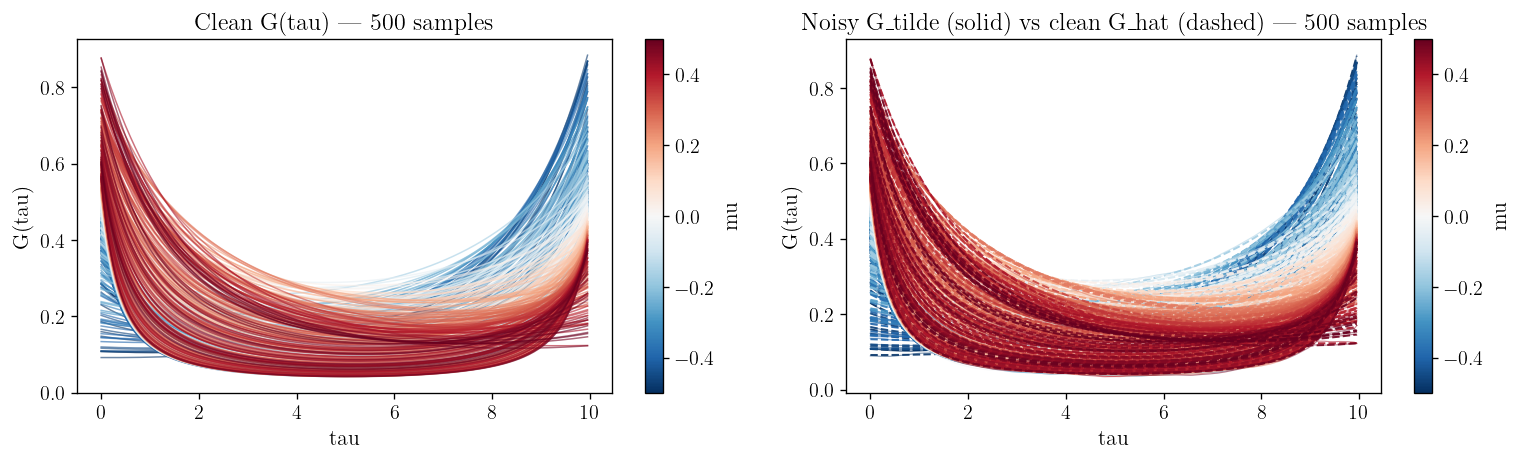

Saved → /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain/plots/greens_functions.pdf


In [6]:
N_SHOW  = 500
rng_vis = np.random.default_rng(1)
idx     = rng_vis.choice(N, size=N_SHOW, replace=False)
idx     = idx[np.argsort(mus[idx])]   # sort by mu for clean color gradient

norm = plt.Normalize(mus.min(), mus.max())
cmap = cm.RdBu_r

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Clean G(tau)
ax = axes[0]
for i in idx:
    ax.plot(taus, G_hat[i], color=cmap(norm(mus[i])), alpha=0.6, linewidth=0.9)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="mu")
ax.set_xlabel("tau")
ax.set_ylabel("G(tau)")
ax.set_title(f"Clean G(tau) — {N_SHOW} samples")

# Noisy G_tilde for a few samples
ax = axes[1]
for i in idx:
    ax.plot(taus, G_tilde[i], color=cmap(norm(mus[i])), alpha=0.5, linewidth=0.7)
    ax.plot(taus, G_hat[i],   color=cmap(norm(mus[i])), alpha=0.9, linewidth=1.2,
            linestyle="--")
plt.colorbar(sm, ax=ax, label="mu")
ax.set_xlabel("tau")
ax.set_ylabel("G(tau)")
ax.set_title(f"Noisy G_tilde (solid) vs clean G_hat (dashed) — {N_SHOW} samples")

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, "greens_functions.pdf")
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path}")

## 5 · Spectral function diversity

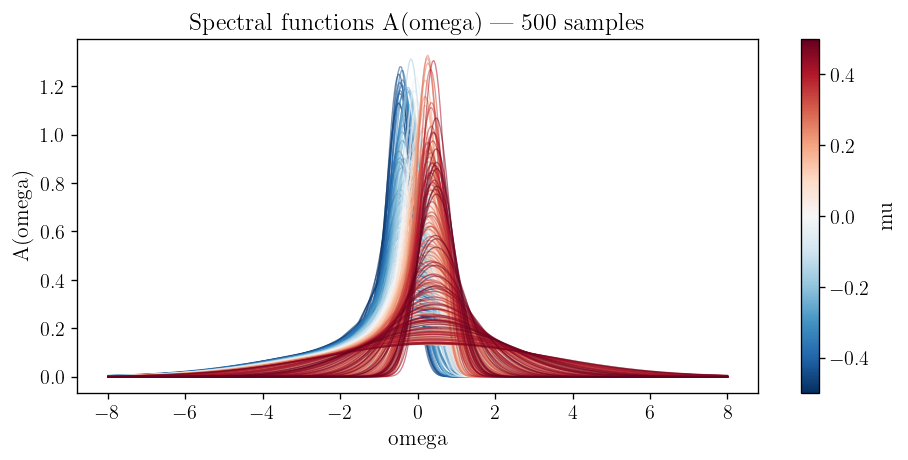

Saved → /Users/georgeissa/Documents/AC/SPE-AC-VAE/Data/datasets/synthetic-gaussian-pretrain/plots/spectral_functions.pdf


In [7]:
omega_grid = np.linspace(-8.0, 8.0, 400)

fig, ax = plt.subplots(figsize=(8, 4))
for i in idx:
    A = np.exp(-0.5 * ((omega_grid - mus[i]) / sigmas[i])**2) / (sigmas[i] * np.sqrt(2 * np.pi))
    ax.plot(omega_grid, A, color=cmap(norm(mus[i])), alpha=0.55, linewidth=0.8)

plt.colorbar(sm, ax=ax, label="mu")
ax.set_xlabel("omega")
ax.set_ylabel("A(omega)")
ax.set_title(f"Spectral functions A(omega) — {N_SHOW} samples")

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, "spectral_functions.pdf")
plt.savefig(save_path, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path}")